<a href="https://colab.research.google.com/github/MEY1337/DeepLeanning-project/blob/main/_%F0%9F%93%8A_House_Prices_(Kaggle)_Deep_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files
uploaded = files.upload()

Saving train.csv to train (1).csv


In [3]:
# 1. 라이브러리 불러오기
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

In [4]:
# 2. 데이터 불러오기
# 캐글에서 train.csv를 다운로드 후 코랩에 업로드해야 함
train = pd.read_csv("train.csv")

print(train.shape)
train.head()

(1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [5]:
# 3. 입력 데이터 X, 정답 데이터 y 분리
# SalePrice는 예측해야 하는 주택 가격이므로 y로 분리
X = train.drop("SalePrice", axis=1)
y = train["SalePrice"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1460, 80)
y shape: (1460,)


In [6]:
# 4. 수치형 데이터만 선택
# 간단한 딥러닝 실습을 위해 숫자형 feature만 사용
X = X.select_dtypes(include=[np.number])

print("사용할 feature 수:", X.shape[1])
X.head()

사용할 feature 수: 37


,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
0,1,60,65.0,8450,7,5,2003,2003,196.0,706,...,548,0,61,0,0,0,0,0,2,2008
1,2,20,80.0,9600,6,8,1976,1976,0.0,978,...,460,298,0,0,0,0,0,0,5,2007
2,3,60,68.0,11250,7,5,2001,2002,162.0,486,...,608,0,42,0,0,0,0,0,9,2008
3,4,70,60.0,9550,7,5,1915,1970,0.0,216,...,642,0,35,272,0,0,0,0,2,2006
4,5,60,84.0,14260,8,5,2000,2000,350.0,655,...,836,192,84,0,0,0,0,0,12,2008


In [7]:
# 5. 결측치 처리
# 비어 있는 값은 각 컬럼의 평균값으로 채움
X = X.fillna(X.mean())

print("결측치 개수:", X.isnull().sum().sum())

결측치 개수: 0


In [8]:
# 6. train / test 데이터 분리
# 학습용 80%, 검증용 20%로 나눔
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)

X_train: (1168, 37)
X_valid: (292, 37)


In [9]:
# 7. 데이터 정규화
# 딥러닝 모델은 입력값의 크기 차이에 영향을 받을 수 있으므로 정규화 수행
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)

In [10]:
# 8. 딥러닝 모델 생성
# MLP: 입력층 → 은닉층 → 출력층 구조
model = Sequential()

model.add(Dense(128, activation="relu", input_shape=(X_train_scaled.shape[1],)))
model.add(BatchNormalization())
model.add(Dropout(0.2))

model.add(Dense(64, activation="relu"))
model.add(BatchNormalization())
model.add(Dropout(0.2))

model.add(Dense(32, activation="relu"))

# 회귀 문제이므로 출력층은 1개
model.add(Dense(1))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         4,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,001 (62.50 KB)

 Trainable params: 15,617 (61.00 KB)

 Non-trainable params: 384 (1.50 KB)

In [11]:
# 9. 모델 컴파일
# 회귀 문제이므로 loss는 mse 사용
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="mse"
)

In [12]:
# 10. 모델 학습
history = model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_valid_scaled, y_valid),
    epochs=100,
    batch_size=32,
    verbose=1
)

Epoch 1/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 38885134336.0000 - val_loss: 39653343232.0000
Epoch 2/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 38883442688.0000 - val_loss: 39651012608.0000
Epoch 3/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 38879674368.0000 - val_loss: 39644160000.0000
Epoch 4/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 38871609344.0000 - val_loss: 39631048704.0000
Epoch 5/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 38857523200.0000 - val_loss: 39610515456.0000
Epoch 6/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 38835908608.0000 - val_loss: 39580221440.0000
Epoch 7/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 38804299776.0000 - val_loss: 39541596160.0000
Epoch 8/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 38763921408.0000 - val_loss: 39491891200.0000
Epoch 9/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 38712270848.0000 - val_loss: 39430037504.0000
Epoch 10/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - 

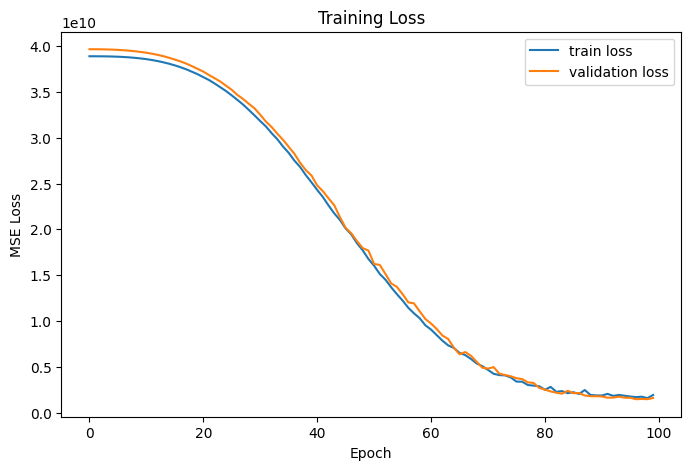

In [13]:
# 11. 학습 과정 시각화
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="validation loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training Loss")
plt.legend()
plt.show()

In [14]:
# 12. 예측 및 RMSE 계산
pred = model.predict(X_valid_scaled)

rmse = np.sqrt(mean_squared_error(y_valid, pred))
print("RMSE:", rmse)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
RMSE: 40029.49952222736


In [15]:
# 13. 실제값과 예측값 비교
result = pd.DataFrame({
    "Actual SalePrice": y_valid.values,
    "Predicted SalePrice": pred.flatten()
})

result.head(10)

,Actual SalePrice,Predicted SalePrice
0,154500,128405.546875
1,325000,315241.968750
2,115000,118341.460938
3,159000,167257.140625
4,315500,304901.406250
5,75500,41199.765625
6,311500,228102.109375
7,146000,131430.031250
8,84500,42748.460938
9,135500,126774.843750


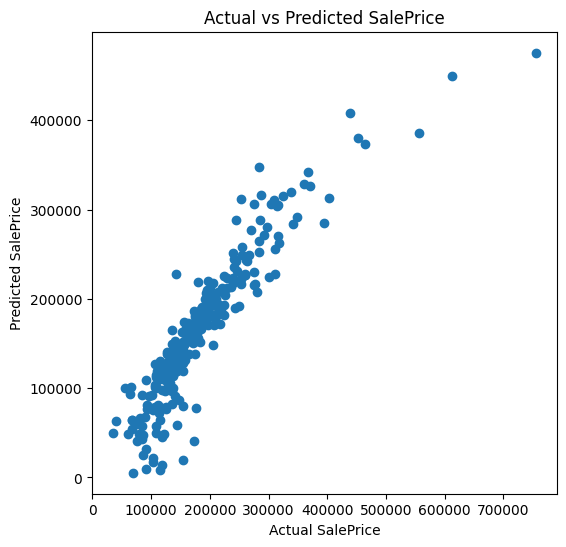

In [16]:
# 14. 실제값 vs 예측값 그래프
plt.figure(figsize=(6, 6))
plt.scatter(y_valid, pred)
plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")
plt.title("Actual vs Predicted SalePrice")
plt.show()

데이터 크기: (1460, 81)

데이터 정보:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-

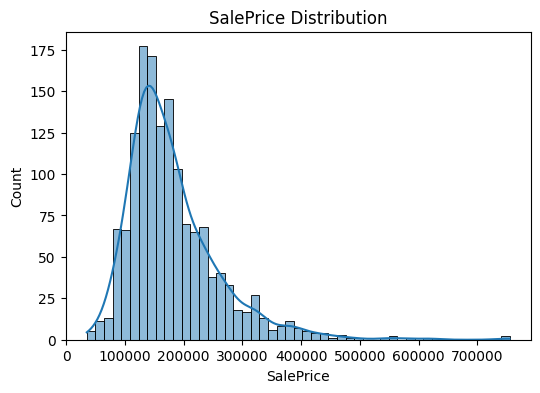

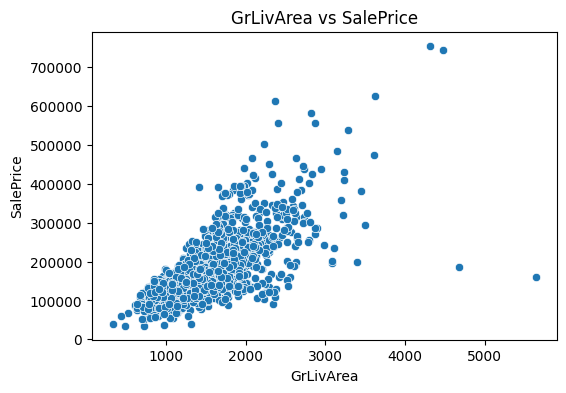

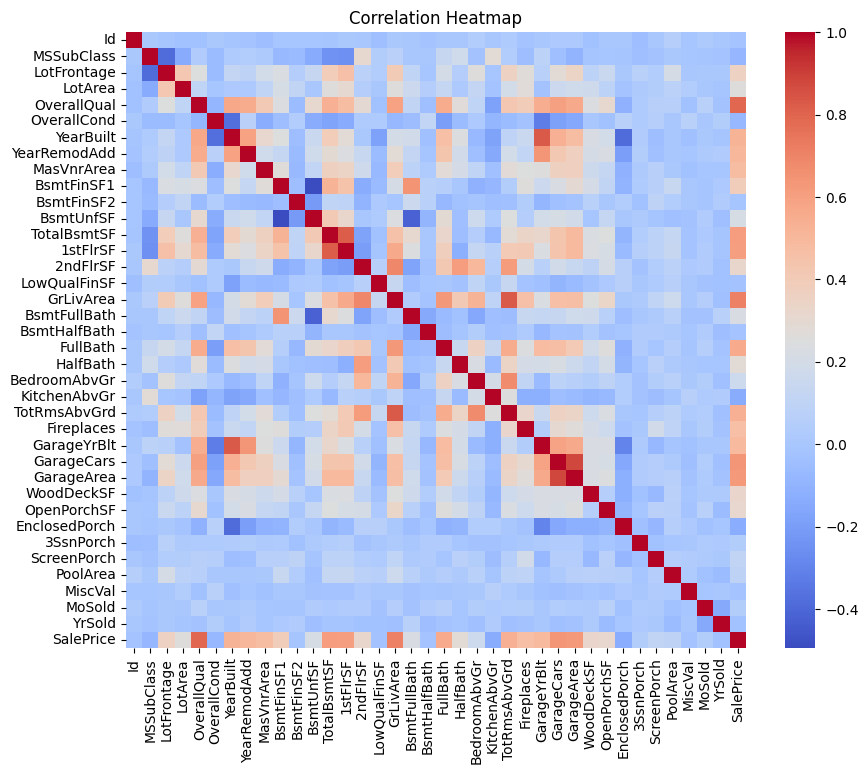

In [17]:
# =========================
# EDA (탐색적 데이터 분석)
# =========================

import seaborn as sns
import matplotlib.pyplot as plt

# 1. 데이터 구조 확인
print("데이터 크기:", train.shape)
print("\n데이터 정보:")
train.info()

# 2. 결측치 확인
print("\n결측치 개수:")
print(train.isnull().sum().sort_values(ascending=False).head(10))

# 3. 타겟 변수 분포
plt.figure(figsize=(6,4))
sns.histplot(train['SalePrice'], kde=True)
plt.title("SalePrice Distribution")
plt.show()

# 4. 주요 변수 관계 확인
plt.figure(figsize=(6,4))
sns.scatterplot(x='GrLivArea', y='SalePrice', data=train)
plt.title("GrLivArea vs SalePrice")
plt.show()

# 5. 상관관계 히트맵
plt.figure(figsize=(10,8))
corr = train.corr(numeric_only=True)
sns.heatmap(corr, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

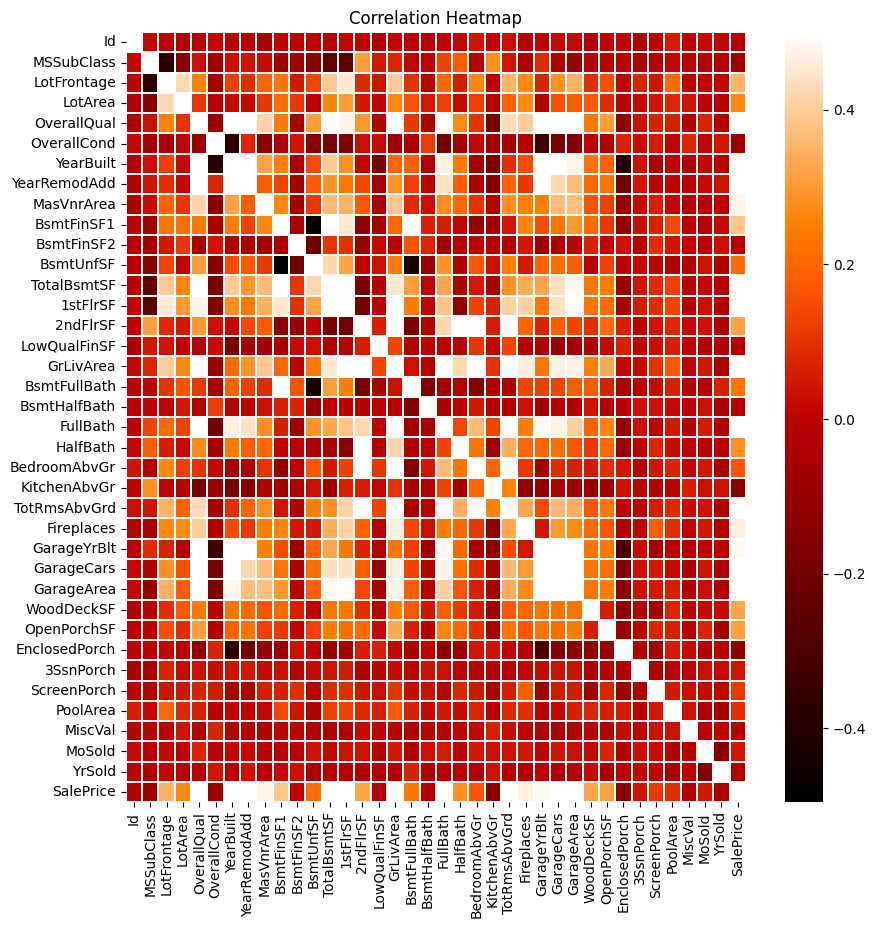

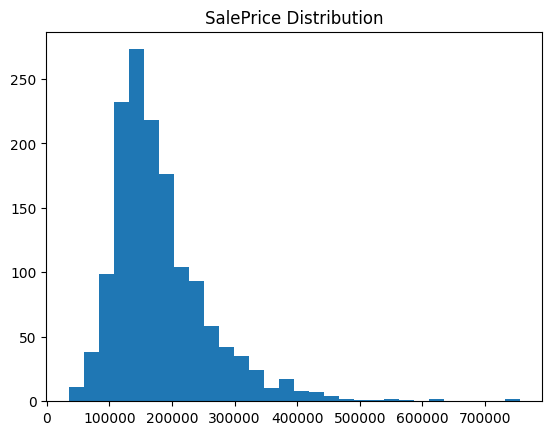

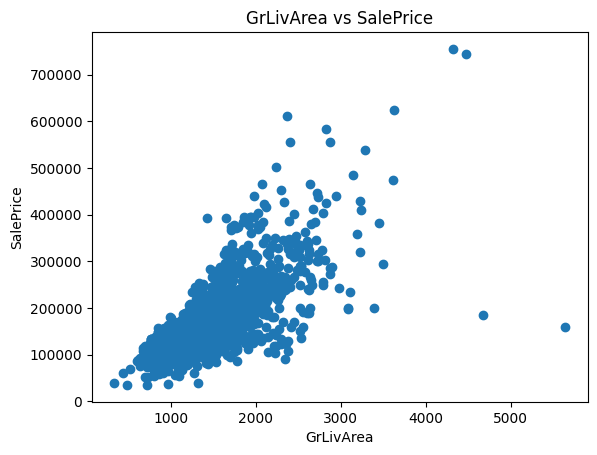

In [18]:
# =========================
# EDA
# =========================

import seaborn as sns
import matplotlib.pyplot as plt

# 1. 데이터 확인
train.head()

# 2. 타겟 변수 분포 확인
train["SalePrice"].describe()

# 3. 전체 데이터 통계
train.describe()

# 4. 결측치 확인
train.isnull().sum()

# 5. 상관관계
train.corr(numeric_only=True)

# 6. 히트맵
colormap = plt.cm.gist_heat
plt.figure(figsize=(10,10))
sns.heatmap(train.corr(numeric_only=True),
            linewidths=0.1,
            vmax=0.5,
            cmap=colormap,
            linecolor='white',
            annot=False)
plt.title("Correlation Heatmap")
plt.show()

# 7. 주요 변수 분포
plt.hist(train['SalePrice'], bins=30)
plt.title("SalePrice Distribution")
plt.show()

# 8. 변수 관계 (예시)
plt.scatter(train['GrLivArea'], train['SalePrice'])
plt.xlabel("GrLivArea")
plt.ylabel("SalePrice")
plt.title("GrLivArea vs SalePrice")
plt.show()

Correlation Heatmap을 통해 일부 변수들이 SalePrice와 높은 상관관계를 가지는 것을 확인할 수 있다. 특히 OverallQual과 GrLivArea는 비교적 높은 상관성을 보이며, 주택 가격에 중요한 영향을 미치는 변수임을 알 수 있다.

SalePrice Distribution 그래프를 보았을 때, 10만~20만 달러 구간의 값이 가장 많이 분포되어 있는 것을 확인할 수 있다. 이는 해당 데이터셋에서 중간 가격대의 주택이 가장 많은 비중을 차지하고 있음을 의미한다. 또한 오른쪽으로 긴 꼬리를 가진 분포를 보이므로 일부 고가 주택이 존재함을 알 수 있다.

GrLivArea와 SalePrice의 산점도를 보면, 거주 면적이 증가할수록 주택 가격이 증가하는 경향이 나타난다. 이는 주택의 크기가 클수록 가격이 높아지는 양의 상관관계를 가지는 것을 의미한다.